<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/spam_or_not_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. File upload

In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam_or_not_spam.csv to spam_or_not_spam.csv


# 2. Import required libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 3. Load the dataset

In [9]:
df = pd.read_csv('spam_or_not_spam.csv')
df.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


# 4. Check shape

In [10]:
df.shape

(3000, 2)

# 5. Check label distribution

In [11]:
df['label'].value_counts()

,count
label,
0,2500
1,500


# 6. Check for missing values

In [12]:
df.isnull().sum()

,0
email,1
label,0


# 7. Drop rows with missing email text

In [13]:
df = df.dropna(subset=['email'])
df.shape

(2999, 2)

# 8. Separate features (X) and target (y)

In [14]:
X = df['email']
y = df['label']

# 9. Split into training and testing sets

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (2399,)
Testing Data Shape: (600,)


# 10. Convert text to numbers (TF-IDF)

In [16]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorized Training Shape:", X_train_vec.shape)
print("Vectorized Testing Shape:", X_test_vec.shape)

Vectorized Training Shape: (2399, 5000)
Vectorized Testing Shape: (600, 5000)


# 11. Create and train the model

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Model Training Completed")

Model Training Completed


# 12. Make predictions on test data

In [18]:
y_pred = model.predict(X_test_vec)

# 13. Calculate accuracy

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.96


# 14. Confusion matrix

Confusion Matrix:
 [[500   0]
 [ 24  76]]


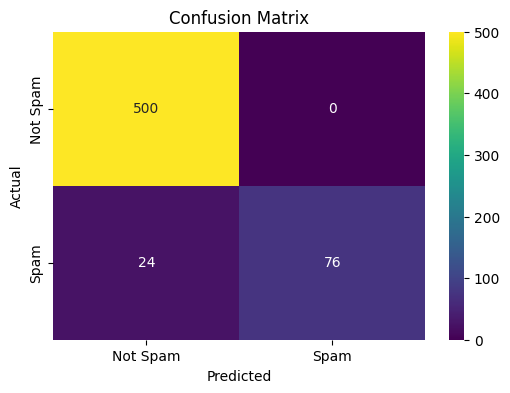

In [20]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 15. Classification report

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       500
           1       1.00      0.76      0.86       100

    accuracy                           0.96       600
   macro avg       0.98      0.88      0.92       600
weighted avg       0.96      0.96      0.96       600

